# Speech Filtration

Computes per-segment quality scores for all transcribed intervals and produces a filtered word df.

**Metrics (segment-level → propagated to words):**
- `word_score` — WhisperX alignment confidence (already in transcript CSV)
- `ctc_loss` — negative mean CTC loss via wav2vec2 (higher = better acoustic-text match)
- `spectral_entropy` — mean spectral entropy (moderate values expected for clean speech)
- `dnsmos_sig/bak/ovrl` — DNSMOS P.835 speech/background/overall quality (higher = better)

**Pipeline:**
1. Scan intervals → submit GPU SLURM jobs (one per interval)
2. Aggregate `quality/segment_quality.csv` outputs
3. Merge scores into word df, preserving `original_word_idx`
4. Plot distributions → filter outliers → save filtered df

In [9]:
import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [10]:
PATIENT = "YFA"
VAD_ROOT    = Path(f"/mnt/labworlds/Hayden/Hayden_Lab/speech_247/vad_new/{PATIENT}")
VAD_DATA_DIR = VAD_ROOT / "vad_data"
TRANSCRIPTS_CSV = VAD_ROOT / f"{PATIENT}_transcripts.csv"

WORKER_PATH    = "/scratch/tahaismail424/speech_247/notebooks/REBIRTH_2!/speech_filtration/quality_worker.py"
CONDA_ACTIVATE = "source /scratch/tahaismail424/.bash_profile && conda activate speech_247_env"
PARTITION      = "guppy"

LOGS_DIR  = VAD_ROOT / "quality_slurm_logs"
BATCH_DIR = VAD_ROOT / "quality_slurm_scripts"
LOGS_DIR.mkdir(parents=True, exist_ok=True)
BATCH_DIR.mkdir(parents=True, exist_ok=True)

print("VAD_ROOT:", VAD_ROOT)
print("TRANSCRIPTS_CSV:", TRANSCRIPTS_CSV)

VAD_ROOT: /mnt/labworlds/Hayden/Hayden_Lab/speech_247/vad_new/YFA
TRANSCRIPTS_CSV: /mnt/labworlds/Hayden/Hayden_Lab/speech_247/vad_new/YFA/YFA_transcripts.csv


## 1 — Scan Intervals & Submit Jobs

In [24]:
ready = []   # transcription done, quality not yet
done  = []   # quality already finished
errored = []

for idir in sorted(VAD_DATA_DIR.iterdir()):
    if not idir.is_dir():
        continue
    tx_ok = (idir / "transcription" / "_SUCCESS").exists()
    qa_ok = (idir / "quality" / "_SUCCESS").exists()
    qa_err = (idir / "quality" / "_ERROR").exists()
    if not tx_ok:
        continue
    if qa_ok:
        done.append(idir.name)
    elif qa_err:
        errored.append(idir.name)
    else:
        ready.append(idir.name)

print(f"Ready to score : {len(ready)}")
print(f"Already done   : {len(done)}")
print(f"Errored        : {len(errored)}")

Ready to score : 0
Already done   : 439
Errored        : 5


In [25]:
submitted = []
failed    = []

# Resubmit errored intervals too if desired
to_submit = ready + errored  # swap to `ready + errored` to retry failures

for interval_id in to_submit:
    sbatch = f"""#!/bin/bash
#SBATCH --job-name=qa_{interval_id}
#SBATCH --partition={PARTITION}
#SBATCH --gres=mps:l40:16
#SBATCH --cpus-per-task=4
#SBATCH --qos=default_tier
#SBATCH --mem=32G
#SBATCH --time=24:00:00
#SBATCH --output={LOGS_DIR}/{interval_id}_%j.out
#SBATCH --error={LOGS_DIR}/{interval_id}_%j.err

set -eo pipefail

{CONDA_ACTIVATE}

export HF_HOME='/scratch/tahaismail424/hf'
export TRANSFORMERS_OFFLINE=1
export HF_HUB_OFFLINE=1
export HF_DATASETS_OFFLINE=1

echo "HOSTNAME: $(hostname)"
echo "START: $(date)"
echo "INTERVAL: {interval_id}"

python "{WORKER_PATH}" "{VAD_DATA_DIR}" "{interval_id}"

echo "END: $(date)"
"""
    sbatch_path = BATCH_DIR / f"{interval_id}.sbatch"
    sbatch_path.write_text(sbatch)
    try:
        res = subprocess.run(
            ["sbatch", str(sbatch_path)], capture_output=True, text=True, check=True
        )
        submitted.append((interval_id, res.stdout.strip()))
        print(f"submitted: {interval_id} -> {res.stdout.strip()}")
    except subprocess.CalledProcessError as e:
        failed.append((interval_id, e.stderr.strip()))
        print(f"FAILED: {interval_id}  {e.stderr.strip()[:80]}")

print(f"\nsubmitted={len(submitted)}, failed={len(failed)}")

submitted: 20240411-093452_0050 -> Submitted batch job 219623
submitted: 20240414-155840_0003 -> Submitted batch job 219624
submitted: 20240414-155840_0044 -> Submitted batch job 219625
submitted: 20240414-155840_0045 -> Submitted batch job 219626
submitted: 20240414-155840_0068 -> Submitted batch job 219627

submitted=5, failed=0


## 2 — Check Job Status

In [11]:
n_tx    = sum(1 for d in VAD_DATA_DIR.iterdir() if d.is_dir() and (d / "transcription" / "_SUCCESS").exists())
n_done  = sum(1 for d in VAD_DATA_DIR.iterdir() if d.is_dir() and (d / "quality" / "_SUCCESS").exists())
n_error = sum(1 for d in VAD_DATA_DIR.iterdir() if d.is_dir() and (d / "quality" / "_ERROR").exists())

print(f"Transcription complete : {n_tx}")
print(f"Quality done           : {n_done} / {n_tx}")
print(f"Quality errors         : {n_error}")
print(f"Still pending          : {n_tx - n_done - n_error}")

Transcription complete : 1065
Quality done           : 1063 / 1065
Quality errors         : 2
Still pending          : 0


## 3 — Aggregate Quality Scores

In [12]:
quality_parts = []
n_missing = 0

for idir in sorted(VAD_DATA_DIR.iterdir()):
    if not idir.is_dir():
        continue
    q_csv = idir / "quality" / "segment_quality.csv"
    if q_csv.exists():
        try:
            df = pd.read_csv(q_csv)
            if not df.empty:
                quality_parts.append(df)
        except Exception as e:
            print(f"[WARN] {q_csv}: {e}")
    elif (idir / "transcription" / "_SUCCESS").exists():
        n_missing += 1

assert quality_parts, "No quality CSVs found — run jobs first"

quality_df = pd.concat(quality_parts, ignore_index=True)
print(f"Segments with quality scores : {len(quality_df)} from {len(quality_parts)} intervals")
print(f"Intervals still missing      : {n_missing}")
quality_df.head()

Segments with quality scores : 80426 from 1028 intervals
Intervals still missing      : 2


,interval_id,segment_idx,segment_start_s,segment_end_s,segment_text,avg_word_score,ctc_loss,spectral_entropy,dnsmos_sig,dnsmos_bak,dnsmos_ovrl
0,20240423-124841_0004,0,43.904,44.675,you,0.607000,-10.852051,1.092645,1.564712,2.004754,1.268242
1,20240423-171352_0000,0,0.131,1.912,Leave everything behind that you don't need!,0.467857,-3.183376,5.751881,1.255438,1.184932,1.203120
2,20240423-171352_0000,1,2.032,3.753,"Oh no, Hinata!",0.740667,-7.399534,5.898562,1.282156,1.143167,1.241740
3,20240423-171352_0000,2,4.113,14.279,"Alright everybody, let's make camp for the night.",0.543375,-5.877318,6.364548,1.023234,1.033242,0.991679
4,20240423-171352_0000,3,14.299,16.900,We'll camp our tents here.,0.526400,-4.879138,6.414194,1.175157,1.144706,1.216141


## 4 — Merge Quality Scores into Word DF

In [13]:
word_df = pd.read_csv(TRANSCRIPTS_CSV)
print(f"Loaded {len(word_df)} words")

# Preserve original index so we can index into GPT embeddings / spike arrays
word_df["original_word_idx"] = word_df.index

score_cols = ["ctc_loss", "spectral_entropy", "dnsmos_sig", "dnsmos_bak", "dnsmos_ovrl"]
word_df = word_df.merge(
    quality_df[["interval_id", "segment_idx"] + score_cols],
    on=["interval_id", "segment_idx"],
    how="left",
)

n_scored = word_df["ctc_loss"].notna().sum()
print(f"Words with quality scores : {n_scored} / {len(word_df)} ({100*n_scored/len(word_df):.1f}%)")

out_path = VAD_ROOT / f"{PATIENT}_word_df_with_quality.csv"
word_df.to_csv(out_path, index=False)
print(f"Saved → {out_path}")
word_df.head()

Loaded 610928 words
Words with quality scores : 610429 / 610928 (99.9%)
Saved → /mnt/labworlds/Hayden/Hayden_Lab/speech_247/vad_new/YFA/YFA_word_df_with_quality.csv


,patient,interval_id,toc,word,word_start_s,word_end_s,word_score,segment_idx,segment_text,segment_start_s,...,utc_word_end,br_word_start,br_word_end,context,original_word_idx,ctc_loss,spectral_entropy,dnsmos_sig,dnsmos_bak,dnsmos_ovrl
0,YFA,20240423-124841_0004,20240423-124841,you,43.904,44.675,0.607,0,you,43.904,...,2024-04-23 20:25:26.637000000,2176526988,2176550118,NaN,0,-10.852051,1.092645,1.564712,2.004754,1.268242
1,YFA,20240423-171352_0000,20240423-171352,Leave,0.131,0.271,0.223,0,Leave everything behind that you don't need!,0.131,...,2024-04-23 22:13:53.345000000,2371743269,2371747469,NaN,1,-3.183376,5.751881,1.255438,1.184932,1.203120
2,YFA,20240423-171352_0000,20240423-171352,everything,0.311,0.571,0.131,0,Leave everything behind that you don't need!,0.131,...,2024-04-23 22:13:53.645000000,2371748669,2371756469,Leave,2,-3.183376,5.751881,1.255438,1.184932,1.203120
3,YFA,20240423-171352_0000,20240423-171352,behind,0.591,0.771,0.239,0,Leave everything behind that you don't need!,0.131,...,2024-04-23 22:13:53.845000000,2371757069,2371762469,Leave everything,3,-3.183376,5.751881,1.255438,1.184932,1.203120
4,YFA,20240423-171352_0000,20240423-171352,that,0.791,0.891,0.708,0,Leave everything behind that you don't need!,0.131,...,2024-04-23 22:13:53.965000000,2371763069,2371766069,Leave everything behind,4,-3.183376,5.751881,1.255438,1.184932,1.203120


## 5 — Score Distributions

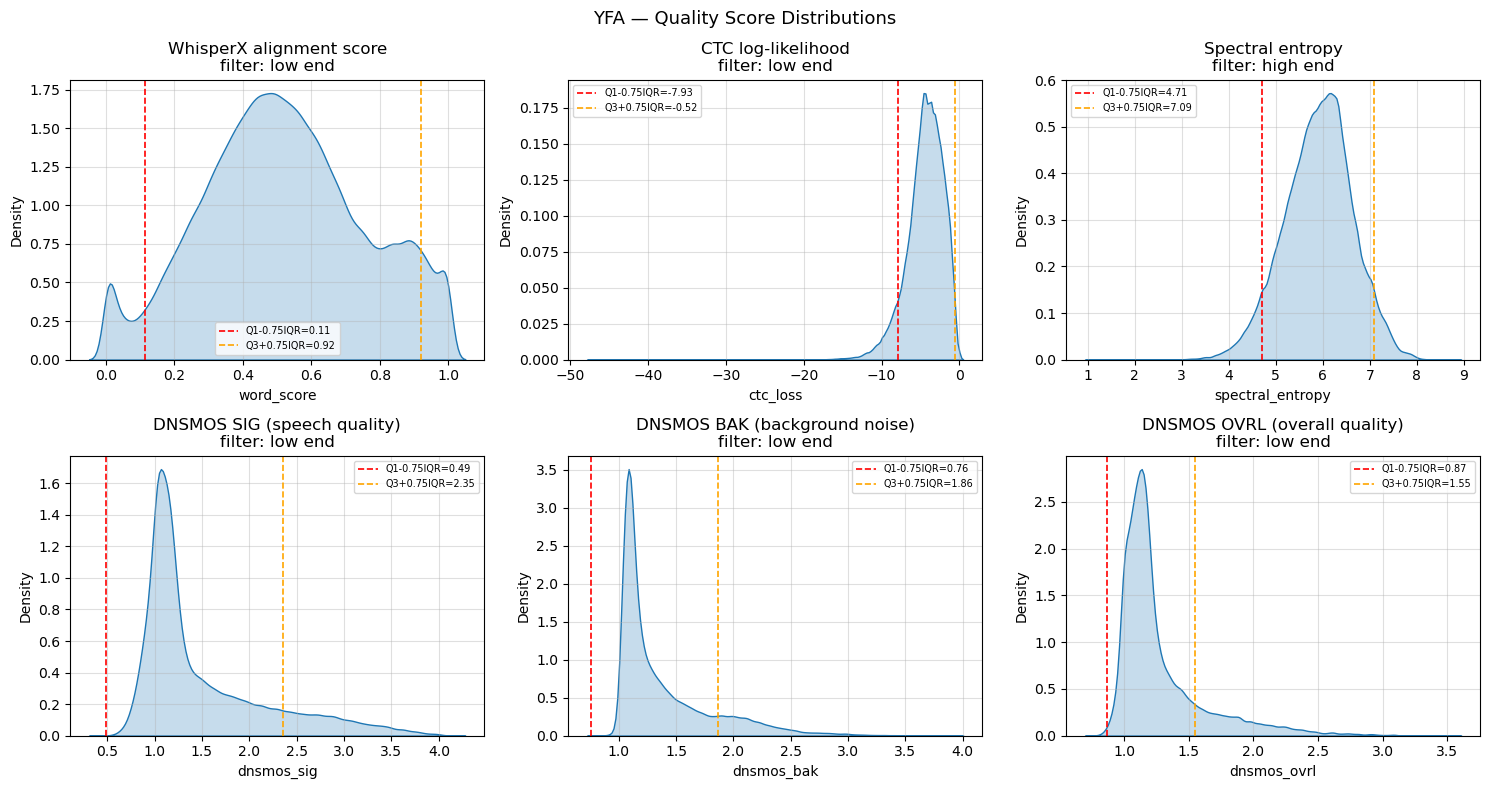

Saved → /mnt/labworlds/Hayden/Hayden_Lab/speech_247/vad_new/YFA/YFA_quality_distributions.png


In [14]:
QUALITY_COLS = {
    "word_score":       ("WhisperX alignment score",      "low end"),
    "ctc_loss":         ("CTC log-likelihood",             "low end"),
    "spectral_entropy": ("Spectral entropy",              "high end"),
    "dnsmos_sig":       ("DNSMOS SIG (speech quality)",    "low end"),
    "dnsmos_bak":       ("DNSMOS BAK (background noise)",  "low end"),
    "dnsmos_ovrl":      ("DNSMOS OVRL (overall quality)",  "low end"),
}

IQR_MULT = 0.75  # standard Tukey fence

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (col, (title, tail)) in zip(axes, QUALITY_COLS.items()):
    if col not in word_df.columns:
        ax.set_title(f"{title}\n(not available)")
        ax.axis("off")
        continue
    data = word_df[col].dropna()
    if len(data) == 0:
        ax.set_title(f"{title}\n(no data)")
        ax.axis("off")
        continue
    q1, q3 = np.nanpercentile(data, [25, 75])
    iqr = q3 - q1
    lo = q1 - IQR_MULT * iqr
    hi = q3 + IQR_MULT * iqr
    sns.kdeplot(data, ax=ax, fill=True)
    ax.axvline(lo, color="red",    linestyle="--", linewidth=1.2, label=f"Q1-{IQR_MULT}IQR={lo:.2f}")
    ax.axvline(hi, color="orange", linestyle="--", linewidth=1.2, label=f"Q3+{IQR_MULT}IQR={hi:.2f}")
    ax.set_title(f"{title}\nfilter: {tail}")
    ax.set_xlabel(col)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)

plt.suptitle(f"{PATIENT} — Quality Score Distributions", fontsize=13)
plt.tight_layout()
fig_path = VAD_ROOT / f"{PATIENT}_quality_distributions.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved → {fig_path}")

## 6 — Filter Words

Each score is treated independently: a word is dropped if **any** of its segment-level scores
falls outside the Tukey fence in the direction that indicates poor quality.

- `word_score`, `ctc_loss`, `dnsmos_*` — flag the **low** tail (these should be as high as possible)
- `spectral_entropy` — flag **both** tails (speech sits in a moderate range)

Adjust `IQR_MULT` below to make filtering more/less aggressive. `original_word_idx` is always preserved so downstream arrays stay aligned.

In [15]:
IQR_MULT = 0.75  # 1.5 = standard, 3.0 = conservative (keep more words)

def low_outlier_mask(series: pd.Series, mult: float) -> pd.Series:
    q1, q3 = np.nanpercentile(series.dropna(), [25, 75])
    return series < (q1 - mult * (q3 - q1))

def high_outlier_mask(series: pd.Series, mult: float) -> pd.Series:
    q1, q3 = np.nanpercentile(series.dropna(), [25, 75])
    return series > (q3 + mult * (q3 - q1))

bad = pd.Series(False, index=word_df.index)

for col in ["word_score", "ctc_loss", "dnsmos_sig", "dnsmos_bak", "dnsmos_ovrl"]:
    if col not in word_df.columns:
        continue
    mask = low_outlier_mask(word_df[col], IQR_MULT)
    print(f"{col:25s} : {mask.sum():>6} words below low fence")
    bad |= mask

if "spectral_entropy" in word_df.columns:
    # lo_mask = low_outlier_mask(word_df["spectral_entropy"], IQR_MULT)
    hi_mask = high_outlier_mask(word_df["spectral_entropy"], IQR_MULT)
    # n = (lo_mask | hi_mask).sum()
    n = (hi_mask).sum()
    print(f"{'spectral_entropy':25s} : {n:>6} words above high fence")
    # bad |= lo_mask | hi_mask
    bad |= hi_mask

print(f"\nWords flagged for removal : {bad.sum()} / {len(word_df)} ({100*bad.mean():.1f}%)")

word_score                :  26857 words below low fence
ctc_loss                  :  48889 words below low fence
dnsmos_sig                :     17 words below low fence
dnsmos_bak                :      0 words below low fence
dnsmos_ovrl               :   1168 words below low fence
spectral_entropy          :  27090 words above high fence

Words flagged for removal : 89568 / 610928 (14.7%)


In [16]:
filtered_df = word_df[~bad].reset_index(drop=True)
print(f"Words retained : {len(filtered_df)} / {len(word_df)}")
print(f"original_word_idx: {filtered_df.original_word_idx.min()} – {filtered_df.original_word_idx.max()}")

filtered_path = VAD_ROOT / f"{PATIENT}_word_df_filtered.csv"
filtered_df.to_csv(filtered_path, index=False)
print(f"Saved → {filtered_path}")
print(f"Columns: {list(filtered_df.columns)}")

Words retained : 521360 / 610928
original_word_idx: 1 – 610927
Saved → /mnt/labworlds/Hayden/Hayden_Lab/speech_247/vad_new/YFA/YFA_word_df_filtered.csv
Columns: ['patient', 'interval_id', 'toc', 'word', 'word_start_s', 'word_end_s', 'word_score', 'segment_idx', 'segment_text', 'segment_start_s', 'segment_end_s', 'speaker', 'interval_utc_start', 'interval_utc_end', 'interval_dur_s', 'br_ts', 'br_te', 'utc_word_start', 'utc_word_end', 'br_word_start', 'br_word_end', 'context', 'original_word_idx', 'ctc_loss', 'spectral_entropy', 'dnsmos_sig', 'dnsmos_bak', 'dnsmos_ovrl']


## 7 — Optional: Words Removed per Metric

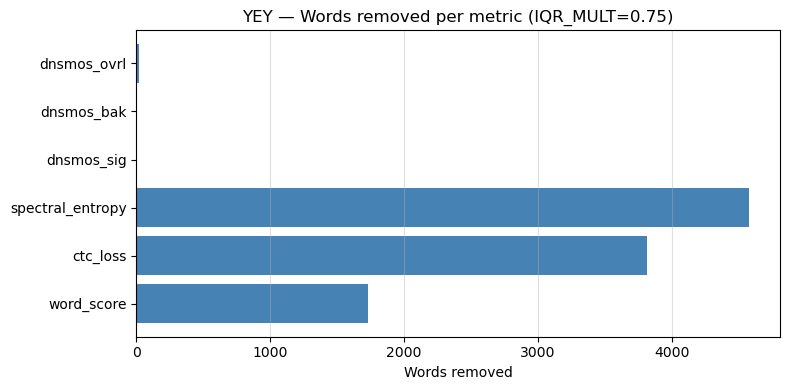

In [9]:
# Bar chart: how many unique words each metric removes (union over all others)
metric_removal = {}
for col in ["word_score", "ctc_loss", "spectral_entropy", "dnsmos_sig", "dnsmos_bak", "dnsmos_ovrl"]:
    if col not in word_df.columns:
        continue
    if col == "spectral_entropy":
        m = low_outlier_mask(word_df[col], IQR_MULT) | high_outlier_mask(word_df[col], IQR_MULT)
    else:
        m = low_outlier_mask(word_df[col], IQR_MULT)
    metric_removal[col] = int(m.sum())

fig, ax = plt.subplots(figsize=(8, 4))
cols = list(metric_removal.keys())
vals = [metric_removal[c] for c in cols]
ax.barh(cols, vals, color="steelblue")
ax.set_xlabel("Words removed")
ax.set_title(f"{PATIENT} — Words removed per metric (IQR_MULT={IQR_MULT})")
ax.grid(True, axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig(VAD_ROOT / f"{PATIENT}_quality_removal_breakdown.png", dpi=150)
plt.show()